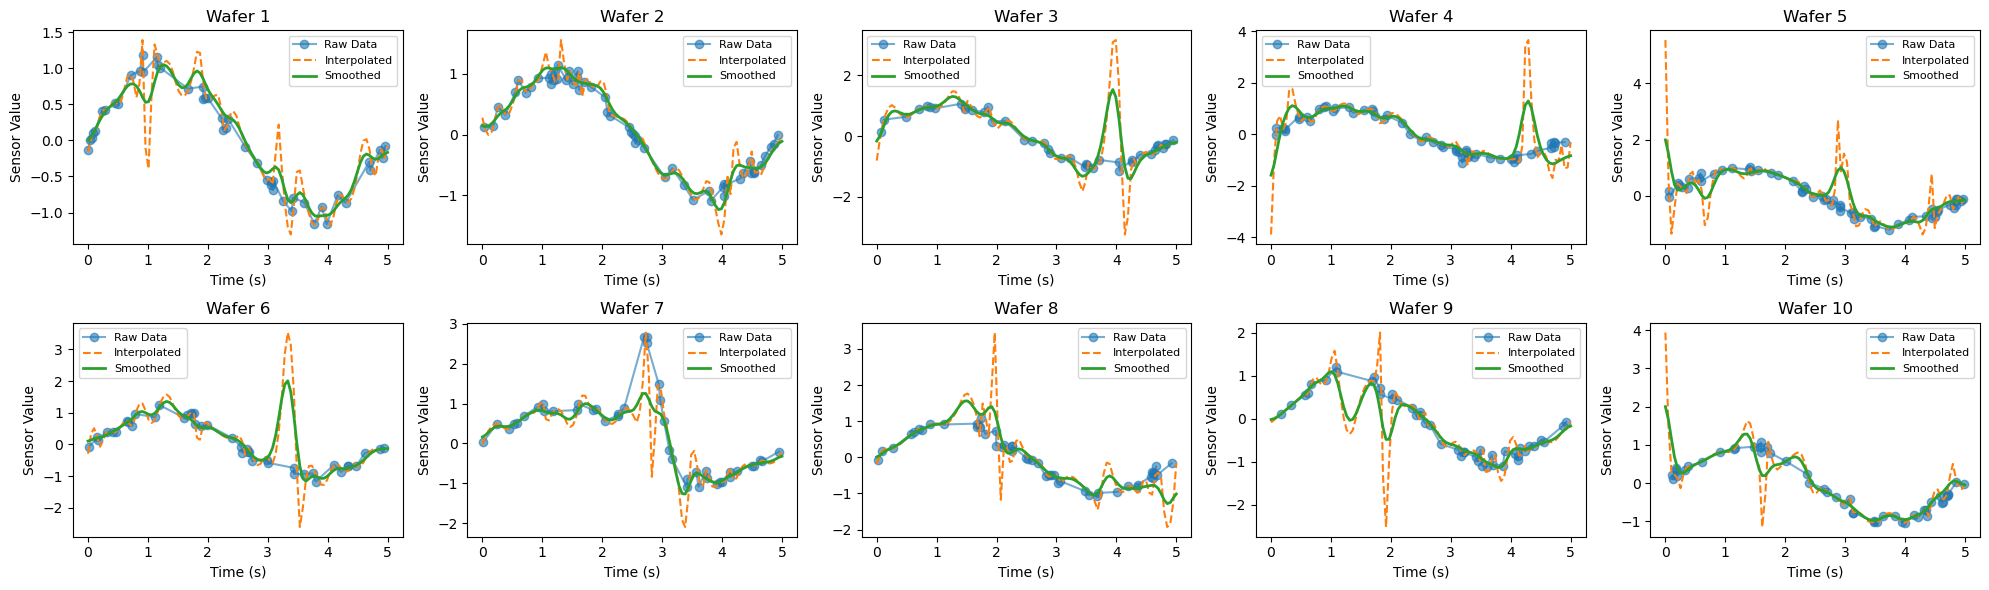

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
0,-0.162755,0.014899,0.132212,0.174090,0.346028,0.419177,0.421472,0.459332,0.514647,0.522654,...,-0.185250,-0.004857,0.015785,-0.123323,-0.413869,-0.494367,-0.230176,-0.122881,-0.240731,-0.076997
1,0.277673,0.074338,-0.006378,0.035526,0.200050,0.434041,0.486568,0.371824,0.320340,0.363512,...,-0.630059,-0.613375,-0.668544,-0.555033,-0.436050,-0.329719,-0.243850,-0.181991,-0.118211,-0.007320
2,-0.805970,-0.148404,0.362394,0.726425,0.943688,1.014185,0.937915,0.796420,0.697944,0.643012,...,-0.585806,-0.608435,-0.546093,-0.424730,-0.282113,-0.390028,-0.305975,-0.251359,-0.210796,-0.127786
3,-3.893017,-1.020706,0.512220,0.718343,0.195488,0.468420,1.717958,1.776181,1.215410,0.777453,...,-0.656026,-0.899216,-1.467115,-1.699853,-0.986630,-1.038989,-0.429288,-1.325545,-1.283353,-0.302712
4,5.540544,0.606612,-1.345015,-0.438755,0.433170,0.337733,0.234159,0.097915,0.766991,0.855118,...,-0.668546,-0.465359,-0.258975,0.028055,0.016141,-0.472026,-0.297433,0.016707,-0.239697,-0.095576
5,-0.295308,0.330143,0.511551,0.248916,-0.071561,0.138598,0.374183,0.442237,0.388404,0.381913,...,-0.687382,-0.569651,-0.382888,-0.246360,-0.165807,-0.141229,-0.151443,-0.150060,-0.135443,-0.107590
6,-0.026217,0.168233,0.317757,0.422353,0.482021,0.496763,0.466577,0.393877,0.352659,0.377806,...,-0.555760,-0.543063,-0.431757,-0.436171,-0.487418,-0.502567,-0.481618,-0.424571,-0.331425,-0.202181
7,-0.187498,0.038326,0.185951,0.255376,0.252349,0.249958,0.270382,0.313622,0.379678,0.463689,...,-0.972441,-1.034219,-0.503238,-0.425536,-0.589548,-1.511185,-1.929130,-1.843386,-1.253951,-0.160825
8,-0.079793,-0.022675,0.035168,0.093737,0.153031,0.213050,0.273795,0.335264,0.397459,0.460379,...,-0.498033,-0.507799,-0.540416,-0.535101,-0.491854,-0.412401,-0.324268,-0.237007,-0.150620,-0.065105
9,3.937487,1.504001,0.269329,0.225243,0.120779,-0.129306,0.247108,0.414282,0.448261,0.475475,...,-0.163282,-0.385565,-0.425386,-0.304888,0.172329,0.502769,0.112348,-0.106711,-0.154385,-0.030675


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# 1. 실제 센서 데이터와 유사한 가상의 wafer 데이터 생성
np.random.seed(42)  # 재현성을 위한 시드 설정
num_wafers = 10  # 10개의 wafer 데이터 생성
max_time = 5  # 최대 공정 시간 (초 단위)
min_length = 40  # 최소 샘플 개수
max_length = 60  # 최대 샘플 개수

wafers = []
for i in range(num_wafers):
    length = np.random.randint(min_length, max_length)  # 서로 다른 길이의 센서 데이터
    time = np.sort(np.random.rand(length) * max_time)  # 0~max_time 사이 랜덤한 시간 샘플링
    # 기본 센서 값 (sine + peak 구조)
    signal = np.sin(2 * np.pi * time / max_time) + np.random.normal(0, 0.1, length)  # 기본 패턴 + 노이즈
    if np.random.rand() < 0.3:  # 일부 웨이퍼에만 피크 추가 (30% 확률)
        peak_time = np.random.uniform(0.3, 0.7) * max_time
        signal += np.exp(-((time - peak_time) ** 2) / 0.1) * np.random.uniform(2, 3)
    wafers.append({"time": time, "signal": signal})

# 2. 정규화 및 보간 (함수형 데이터로 변환)
common_grid = np.linspace(0, 1, 100)  # 공통 시간 그리드 (0~1 정규화)
aligned_data = []  # 보간 후 센서 곡선 저장
for wafer in wafers:
    time, signal = wafer["time"], wafer["signal"]
    norm_time = time / time[-1]  # 시간 정규화 (0~1 범위)
    spline = interp1d(norm_time, signal, kind='quadratic', fill_value="extrapolate")
    aligned_signal = spline(common_grid)
    aligned_data.append(aligned_signal)
aligned_data = np.array(aligned_data)

# 3. 커널 스무딩 (옵션 적용)
smoothed_data = np.array([gaussian_filter1d(signal, sigma=2) for signal in aligned_data])

# 4. 데이터 시각화 (원본 vs 보간 vs 스무딩된 데이터)
plt.figure(figsize=(20, 6))
for i in range(num_wafers):
    plt.subplot(2, 5, i + 1)
    plt.plot(wafers[i]["time"], wafers[i]["signal"], 'o-', alpha=0.6, label="Raw Data")
    plt.plot(common_grid * max_time, aligned_data[i], '--', label="Interpolated")
    plt.plot(common_grid * max_time, smoothed_data[i], '-', label="Smoothed", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Sensor Value")
    plt.legend(fontsize=8)
    plt.title(f"Wafer {i+1}")
plt.tight_layout()
plt.show()

# 결과 데이터 반환
#import ace_tools as tools
import pandas as pd

df = pd.DataFrame(aligned_data, columns=[f"t_{i}" for i in range(100)])
display(df)
#tools.display_dataframe_to_user(name="Aligned Wafer Sensor Data", dataframe=df)

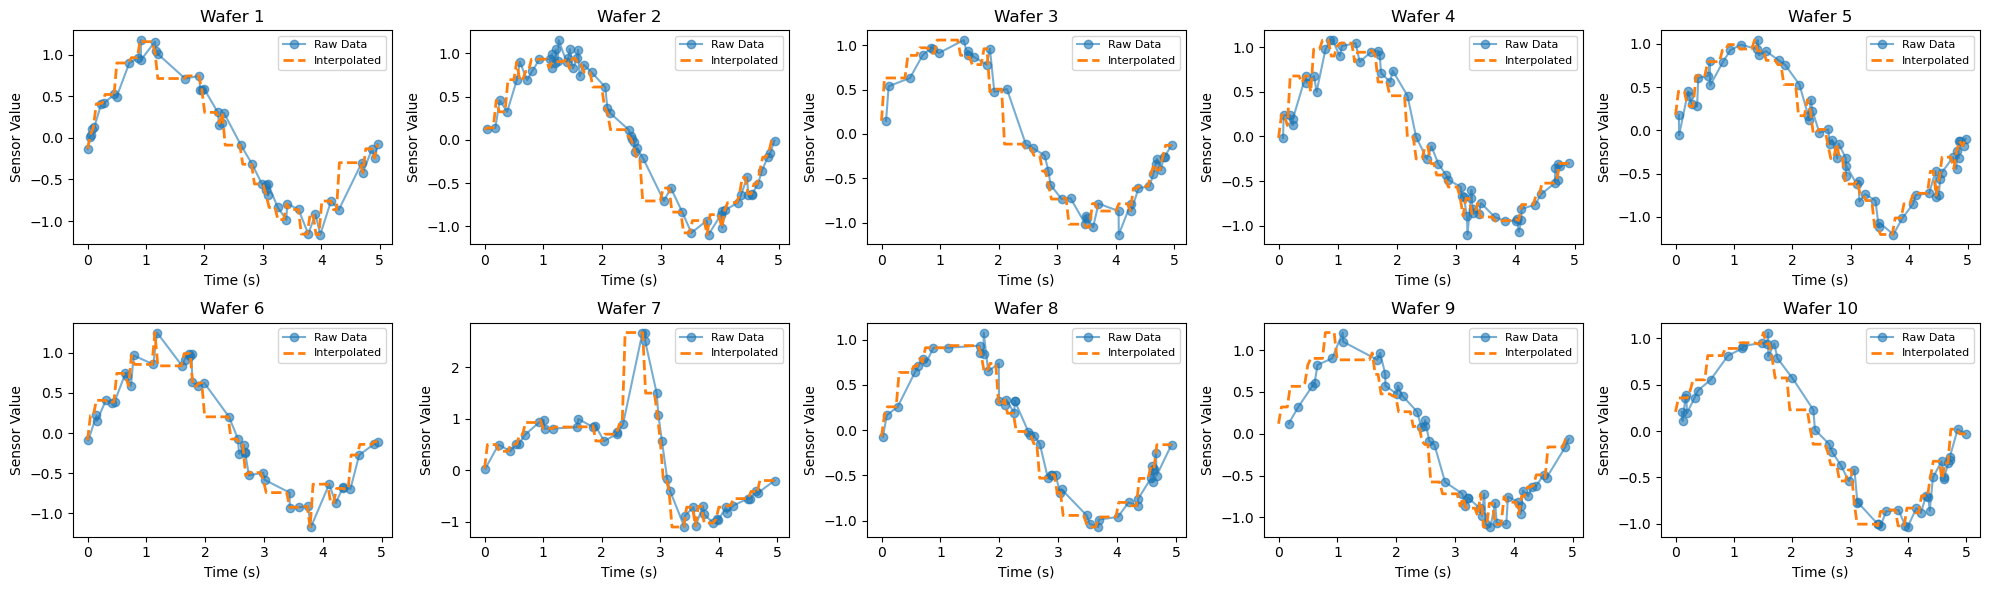

In [40]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# 1. 정규화 및 보간 (함수형 데이터로 변환)
common_grid = np.linspace(0, 1, 100)  # 공통 시간 그리드 (0~1 정규화)
aligned_data = []  # 보간 후 센서 곡선 저장

for wafer in wafers:
    time, signal = wafer["time"], wafer["signal"]
    
    # 0~1 범위로 정규화 (최소값을 0으로 만들기)
    norm_time = (time - time.min()) / (time.max() - time.min())  
    
    # 3차 스플라인 보간 함수 생성 (외삽 가능하도록 `fill_value="extrapolate"`)
    spline = interp1d(norm_time, signal, kind='next', fill_value="extrapolate")
    
    # 공통 시간 그리드로 보간 (함수형 데이터 표현)
    aligned_signal = spline(common_grid)
    
    aligned_data.append(aligned_signal)

aligned_data = np.array(aligned_data)  # 배열 형태 (samples x time_grid)

# 2. 보간된 데이터 시각화 (원본 vs 보간 후 데이터)
plt.figure(figsize=(20, 6))
for i, wafer in enumerate(wafers):
    plt.subplot(2, 5, i + 1)
    plt.plot(wafer["time"], wafer["signal"], 'o-', alpha=0.6, label="Raw Data")
    plt.plot(common_grid * wafer["time"].max(), aligned_data[i], '--', label="Interpolated", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Sensor Value")
    plt.legend(fontsize=8)
    plt.title(f"Wafer {i+1}")
plt.tight_layout()
plt.show()

In [24]:
from scipy.ndimage import gaussian_filter1d

smoothed_data = []
for signal in aligned_data:
    # sigma 값에 따라 매끄럽게 정도 조절 (예: sigma=2)
    smooth_signal = gaussian_filter1d(signal, sigma=2)
    smoothed_data.append(smooth_signal)
smoothed_data = np.array(smoothed_data)
# 만약 스무딩을 사용하지 않으려면 smoothed_data 대신 aligned_data를 그대로 사용

In [49]:
import numpy as np

# 준비: X = (n_samples x m_points) 형태의 데이터 행렬 (각 샘플이 한 행)
X = smoothed_data  # 또는 aligned_data (전처리된 데이터 사용)
n_samples, n_points = X.shape

# 1. 평균 함수 계산 및 중심화
X_mean = X.mean(axis=0)              # 각 열의 평균 (시간별 평균 곡선)
X_centered = X - X_mean              # 평균을 뺀 centered data

# 2. SVD를 사용한 PCA 수행
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
# U: 좌측 특이벡터 (n_samples x n_samples), 
# S: 특이값 벡터, Vt: 우측 특이벡터 전치 (n_samples x n_points)

# 3. 고유함수(eigenfunctions) 및 분산 계산
# SVD 결과에서 Vt의 첫 r행(row)이 상위 r개의 고유함수의 이산값 표현 (길이 m_points)
r = 5  # 사용할 주성분 개수 (예: 5개 선택)
eigenfunctions = Vt[:r]             # (r x m_points) 행렬, 각 행이 고유함수 (이산화된 값)
eigenvalues = (S**2) / (n_samples - 1)  # 공분산 고유값 (분산)
explained_var_ratio = eigenvalues / eigenvalues.sum()

print("주성분별 분산 설명 비율:", explained_var_ratio[:r])

주성분별 분산 설명 비율: [0.25567791 0.24798461 0.19388917 0.11308648 0.08126161]


In [26]:
# K개의 주성분을 사용하여 각 곡선을 재구성하고 오류 계산
K = 3  # 사용할 FPCA 주성분 수 (예: 3개)
phi = eigenfunctions[:K]            # (K x m_points) 상위 K개 고유함수
scores = X_centered.dot(phi.T)      # 각 곡선의 FPCA 점수 (n_samples x K)
X_recon = X_mean + scores.dot(phi)  # 재구성된 곡선들 (n_samples x m_points)

# 재구성 오류 계산 (L2 노름)
recon_errors = np.linalg.norm(X - X_recon, axis=1)  # 각 샘플별 오류 (유클리드 거리)

# 이상치 판단 (예: 오류가 평균 + 3표준편차를 넘는 경우)
threshold = recon_errors.mean() + 3*recon_errors.std()
anomalies = np.where(recon_errors > threshold)[0]
print("이상 탐지된 웨이퍼 인덱스:", anomalies)


이상 탐지된 웨이퍼 인덱스: []


In [27]:
from sklearn.cluster import KMeans

# 예를 들어, 첫 2개의 FPCA 점수를 사용하여 2차원 특징 구성
feature_scores = scores[:, :2]  # (n_samples x 2) 배열, 각 샘플의 PC1, PC2 점수
# K-평균 군집화 실행 (군집 수 k는 도메인 지식이나 Elbow method 등으로 결정)
k = 3  # 군집 개수 가정
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
labels = kmeans.fit_predict(feature_scores)

# 결과 출력
for i in range(k):
    cluster_indices = np.where(labels == i)[0]
    print(f"군집 {i}에 속한 웨이퍼 인덱스: {cluster_indices}")


군집 0에 속한 웨이퍼 인덱스: [3 7]
군집 1에 속한 웨이퍼 인덱스: [0 1 4 5 6 8 9]
군집 2에 속한 웨이퍼 인덱스: [2]


C:\Users\HYKP\miniconda3\envs\python310\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\HYKP\miniconda3\envs\python310\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


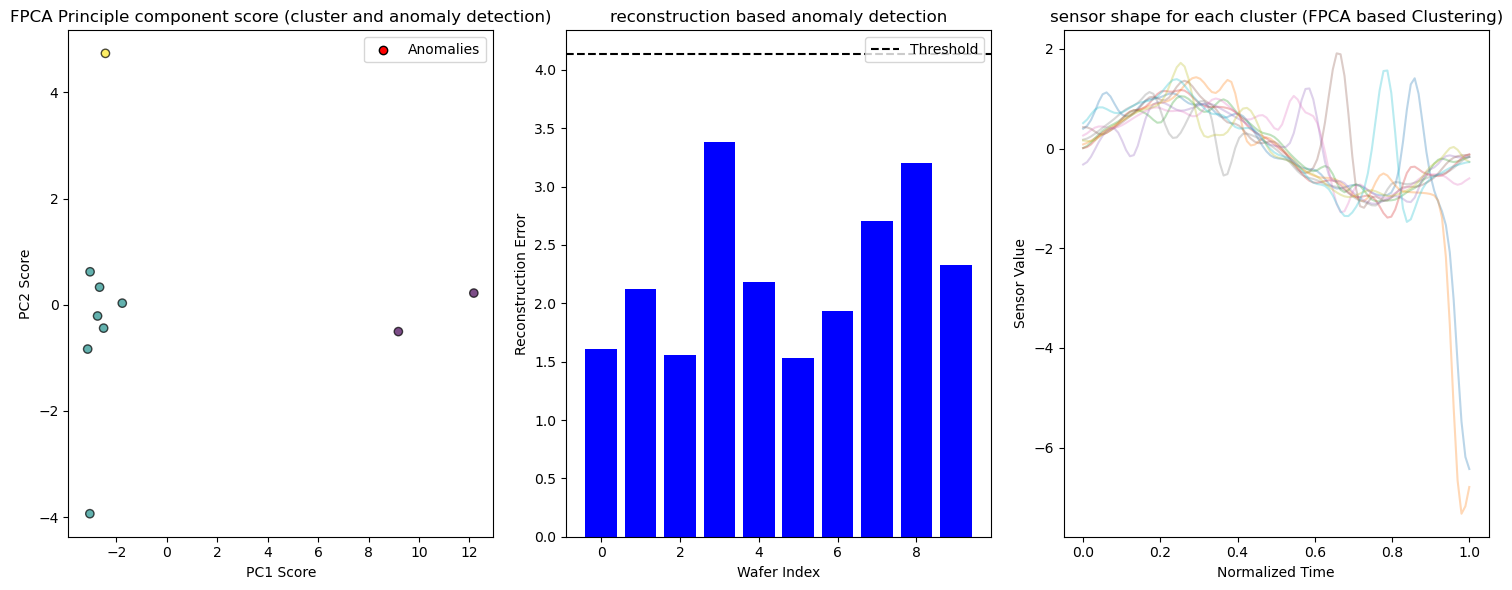

In [31]:
# 필요한 라이브러리 다시 불러오기 (코드 실행 상태가 리셋됨)
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans

# 1. 실제 센서 데이터와 유사한 가상의 wafer 데이터 생성
np.random.seed(42)  # 재현성을 위한 시드 설정
num_wafers = 10  # 10개의 wafer 데이터 생성
max_time = 5  # 최대 공정 시간 (초 단위)
min_length = 40  # 최소 샘플 개수
max_length = 60  # 최대 샘플 개수

wafers = []
for i in range(num_wafers):
    length = np.random.randint(min_length, max_length)  # 서로 다른 길이의 센서 데이터
    time = np.sort(np.random.rand(length) * max_time)  # 0~max_time 사이 랜덤한 시간 샘플링
    # 기본 센서 값 (sine + peak 구조)
    signal = np.sin(2 * np.pi * time / max_time) + np.random.normal(0, 0.1, length)  # 기본 패턴 + 노이즈
    if np.random.rand() < 0.3:  # 일부 웨이퍼에만 피크 추가 (30% 확률)
        peak_time = np.random.uniform(0.3, 0.7) * max_time
        signal += np.exp(-((time - peak_time) ** 2) / 0.1) * np.random.uniform(2, 3)
    wafers.append({"time": time, "signal": signal})

# 2. 정규화 및 보간 (함수형 데이터로 변환)
common_grid = np.linspace(0, 1, 100)  # 공통 시간 그리드 (0~1 정규화)
aligned_data = []  # 보간 후 센서 곡선 저장

for wafer in wafers:
    time, signal = wafer["time"], wafer["signal"]
    norm_time = (time - time.min()) / (time.max() - time.min())  # 시간 정규화
    spline = interp1d(norm_time, signal, kind='cubic', fill_value="extrapolate")
    aligned_signal = spline(common_grid)
    aligned_data.append(aligned_signal)

aligned_data = np.array(aligned_data)  # 배열 형태 (samples x time_grid)

# 3. 커널 스무딩 (옵션 적용)
smoothed_data = np.array([gaussian_filter1d(signal, sigma=2) for signal in aligned_data])

# 4. FPCA 적용 (SVD 기반)
X = smoothed_data  # 또는 aligned_data 사용 가능
X_mean = X.mean(axis=0)  # 평균 함수
X_centered = X - X_mean  # 평균을 제거하여 중심화

# SVD 수행 (FPCA 계산)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
r = 3  # 사용할 주성분 개수
eigenfunctions = Vt[:r]  # (r x time_grid) 각 행이 고유함수
scores = X_centered @ eigenfunctions.T  # 주성분 점수 (n_samples x r)

# 5. 재구성 오류 기반 이상 탐지 (Anomaly Detection)
X_recon = X_mean + scores @ eigenfunctions  # FPCA 기반 재구성
recon_errors = np.linalg.norm(X - X_recon, axis=1)  # 각 웨이퍼별 L2 노름 오류
threshold = recon_errors.mean() + 3 * recon_errors.std()  # 평균+3표준편차 임계값
anomalies = np.where(recon_errors > threshold)[0]  # 이상치 인덱스

# 6. FPCA 점수를 활용한 K-평균 군집화 (Clustering)
k = 3  # 클러스터 개수
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
labels = kmeans.fit_predict(scores[:, :2])  # 첫 2개 주성분으로 군집화

# 7. 시각화
plt.figure(figsize=(15, 6))

# (1) FPCA 주성분 점수 시각화
plt.subplot(1, 3, 1)
plt.scatter(scores[:, 0], scores[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.7)
plt.scatter(scores[anomalies, 0], scores[anomalies, 1], color='red', edgecolors='k', label='Anomalies')
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("FPCA Principle component score (cluster and anomaly detection)")
plt.legend()

# (2) 이상 탐지 시각화 (재구성 오류)
plt.subplot(1, 3, 2)
plt.bar(range(len(recon_errors)), recon_errors, color=['red' if i in anomalies else 'blue' for i in range(len(recon_errors))])
plt.axhline(threshold, color='black', linestyle='--', label="Threshold")
plt.xlabel("Wafer Index")
plt.ylabel("Reconstruction Error")
plt.title("reconstruction based anomaly detection")
plt.legend()

# (3) 군집별 곡선 시각화
plt.subplot(1, 3, 3)
for i in range(k):
    cluster_indices = np.where(labels == i)[0]
    for idx in cluster_indices:
        plt.plot(common_grid, smoothed_data[idx], alpha=0.3)
plt.xlabel("Normalized Time")
plt.ylabel("Sensor Value")
plt.title("sensor shape for each cluster (FPCA based Clustering)")

plt.tight_layout()
plt.show()

# 결과 데이터 테이블 반환
#import ace_tools as tools
import pandas as pd

df = pd.DataFrame({
    "PC1 Score": scores[:, 0],
    "PC2 Score": scores[:, 1],
    "Reconstruction Error": recon_errors,
    "Cluster Label": labels,
    "Anomaly": ["Yes" if i in anomalies else "No" for i in range(len(recon_errors))]
})
#tools.display_dataframe_to_user(name="FPCA Anomaly Detection & Clustering Results", dataframe=df)


In [9]:
df.values[0]

array([-0.16275471,  0.01489911,  0.13221213,  0.17408981,  0.34602836,
        0.41917667,  0.42147181,  0.45933242,  0.51464707,  0.52265427,
        0.49704493,  0.5536395 ,  0.71235218,  0.88009647,  0.91381855,
        0.81194591,  0.59394439,  0.78404166,  1.38887429, -0.10718704,
       -0.39196423,  0.63342931,  1.32759771,  1.17918773,  1.001738  ,
        1.08088387,  1.09970668,  1.05820645,  0.95638316,  0.80076569,
        0.67911398,  0.61899566,  0.62041073,  0.6833592 ,  0.80784107,
        0.99385632,  1.22596429,  1.21140648,  0.83877038,  0.57920935,
        0.58273979,  0.5872719 ,  0.62462963,  0.62588776,  0.45345277,
        0.13948192,  0.20138099,  0.35446272,  0.40329377,  0.34341119,
        0.19409391,  0.05674378, -0.05391335, -0.13787749, -0.19514863,
       -0.23833686, -0.30179472, -0.38746518, -0.4945338 , -0.55693276,
       -0.53277257, -0.61083267, -0.18333169,  0.21778468, -0.36359214,
       -0.86051536, -1.19586351, -1.30429418, -0.90581514, -0.43

In [4]:
import numpy as np

In [121]:
import pandas as pd

data = pd.read_csv('shape_detection_example_dataset.csv')

In [122]:
type_list = [df['TYPE'].unique()[0] for _, df in data.groupby('WAFER_ID')]
df_list = [df for _, df in data.groupby('WAFER_ID')]

In [59]:
data_matrix = data['PARAMETER_VALUE'].values.reshape(-1, 402)

In [31]:
train_matrix = data_matrix[:10]
test_matrix = data_matrix[:15]

# FPCA

In [60]:
import skfda
import scipy
from skfda.preprocessing.dim_reduction import FPCA
#data_matrix = .values
import matplotlib.pyplot as plt
grid_points = np.linspace(start=0, stop=401, num=402)

# X = fd
fd = skfda.FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points)

In [61]:
train_set = fd
test_set = fd

In [62]:
from scipy.stats import gaussian_kde

from skfda.datasets._samples_generators import make_gaussian_process
from skfda.misc.covariances import Exponential, Gaussian
from skfda.misc.metrics import l2_distance, l2_norm
from skfda.preprocessing.dim_reduction import FPCA

In [63]:
q = 1
fpca_clean = FPCA(n_components=q)
fpca_clean.fit(train_set)
train_set_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(train_set)
)

err_train = l2_distance(
    train_set,
    train_set_hat
) / l2_norm(train_set)

test_set_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(test_set)
)
err_test = l2_distance(
    test_set,
    test_set_hat
) / l2_norm(test_set)

In [ ]:
dat

In [137]:
t = np.arange(len(err_train))

In [181]:
thres = np.std(err_train, ddof=1)


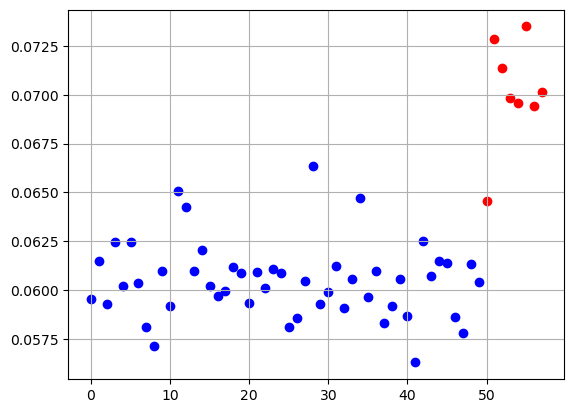

In [183]:
color='blue'
#plt.axhline(thres)
for idx, (x, y) in enumerate(zip(t, err_train)):
    if idx > 49:
        color='red'
    plt.scatter(x,y, color=color)
plt.grid(True)

In [155]:
mean = np.mean(data_matrix, axis=1)
rms = np.sqrt(np.mean(data_matrix**2, axis=1))
crest = np.max(np.abs(data_matrix), axis=1) / rms
shape = rms/mean
p2p = np.abs(np.max(data_matrix, axis=1) - np.min(data_matrix, axis=1))
impulse = p2p/mean
#cif = np.square(np.mean(np.sqrt(data_matrix), axis=1))
#margin = p2p / np.square(np.mean(np.sqrt(data_matrix), axis=1))
waveform_entropy = crest * np.log(crest)

In [170]:
data_stat = pd.DataFrame(
    data=[mean, rms, crest, shape, p2p, impulse, waveform_entropy],
    index=['mean', 'rms', 'crest', 'shape', 'p2p', 'impulse', 'waveform_entropy']
).T

In [176]:
data_stat

,mean,rms,crest,shape,p2p,impulse,waveform_entropy
0,0.766102,0.811139,1.372063,1.058787,1.129857,1.474812,0.434005
1,0.763804,0.810893,1.377082,1.061650,1.168734,1.530148,0.440620
2,0.766651,0.811490,1.406370,1.058487,1.203239,1.569475,0.479589
3,0.764498,0.809886,1.344060,1.059369,1.184262,1.549071,0.397432
4,0.769374,0.815840,1.402763,1.060395,1.206555,1.568229,0.474756
5,0.761156,0.805809,1.437199,1.058665,1.242309,1.632135,0.521267
6,0.764050,0.808995,1.376731,1.058825,1.128767,1.477347,0.440158
7,0.766485,0.810241,1.351292,1.057086,1.110674,1.449049,0.406821
8,0.769027,0.812948,1.385835,1.057112,1.128884,1.467938,0.452202
9,0.767276,0.811935,1.404456,1.058204,1.230520,1.603751,0.477023


In [187]:
df = data

In [196]:
peak_indices = {}
for wafer_id, group in df.groupby('WAFER_ID')['PARAMETER_VALUE']:
    values = group.to_numpy()
    peak_idx = np.argmax(values)
    peak_indices[wafer_id] = peak_idx

# 평균 - 3표준편차로 임계값 설정 (예시)
peak_idx_values = np.array(list(peak_indices.values()))
thr = peak_idx_values.mean() - 3*peak_idx_values.std()
anomalies = [w for w, idx in peak_indices.items() if idx < thr]
print("피크가 너무 빠른 이상 웨이퍼:", anomalies)

피크가 너무 빠른 이상 웨이퍼: []


In [197]:
# wafer_data는 {wafer_id: PARAMETER_VALUE 시계열} 형태의 dict라고 가정
all_curves = np.column_stack(list(wafer_data.values()))
median_curve = np.median(all_curves, axis=1)
lower_band = np.percentile(all_curves, 5, axis=1)
upper_band = np.percentile(all_curves, 95, axis=1)

outliers = []
for wafer_id, series in wafer_data.items():
    series = np.array(series)
    if np.any(series < lower_band) or np.any(series > upper_band):
        outliers.append(wafer_id)
print("5~95% envelope 초과한 이상 곡선:", outliers)

5~95% envelope 초과한 이상 곡선: ['wafer1', 'wafer10', 'wafer11', 'wafer12', 'wafer13', 'wafer14', 'wafer15', 'wafer16', 'wafer17', 'wafer18', 'wafer19', 'wafer2', 'wafer20', 'wafer21', 'wafer22', 'wafer23', 'wafer24', 'wafer25', 'wafer26', 'wafer27', 'wafer28', 'wafer29', 'wafer3', 'wafer30', 'wafer31', 'wafer32', 'wafer33', 'wafer34', 'wafer35', 'wafer36', 'wafer37', 'wafer38', 'wafer39', 'wafer4', 'wafer40', 'wafer41', 'wafer42', 'wafer43', 'wafer44', 'wafer45', 'wafer46', 'wafer47', 'wafer48', 'wafer49', 'wafer5', 'wafer50', 'wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58', 'wafer6', 'wafer7', 'wafer8', 'wafer9']


In [198]:
import numpy as np

ref_pattern = median_curve  # 앞서 구한 정상 곡선 중앙값

def pearson_corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

outliers = []
for wafer_id, series in wafer_data.items():
    series = np.array(series)
    corr = pearson_corr(series, ref_pattern)
    if corr < 0.8:
        outliers.append((wafer_id, corr))
print("상관계수 낮은 이상 웨이퍼:", outliers)

상관계수 낮은 이상 웨이퍼: [('wafer51', 0.7014397075722341), ('wafer52', 0.7115774677326098), ('wafer53', 0.7182174257710704), ('wafer54', 0.723493692945122), ('wafer55', 0.7096777018543395), ('wafer56', 0.7115646776059628), ('wafer57', 0.6990724497007395), ('wafer58', 0.7035804902925554)]


In [203]:
# X: shape (n_wafers, time_length), wafer 시계열들을 행으로 쌓은 행렬
X = np.vstack([series for series in wafer_data.values()])
X_mean = X.mean(axis=0)
X_centered = X - X_mean

pca = PCA(n_components=5)
X_pcs = pca.fit_transform(X_centered)
X_reconst = pca.inverse_transform(X_pcs)
recon_errors = np.mean((X_centered - X_reconst)**2, axis=1)

threshold = np.percentile(recon_errors, 95)
outliers = [wafer_id for wafer_id, err in zip(wafer_data.keys(), recon_errors) if err > threshold]
print("재구성 오차 기반 이상 웨이퍼:", outliers)

재구성 오차 기반 이상 웨이퍼: ['wafer52', 'wafer54', 'wafer56']


In [204]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X_pcs[:, :2])  # 첫 2개 주성분 사용
cluster_sizes = np.bincount(labels)
anomaly_cluster = np.argmin(cluster_sizes)
anomaly_indices = np.where(labels == anomaly_cluster)[0]
anomaly_wafers = [list(wafer_data.keys())[i] for i in anomaly_indices]
print("작은 군집 (이상 추정):", anomaly_wafers)

작은 군집 (이상 추정): ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


C:\Users\HYKP\miniconda3\envs\python310\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [205]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel='rbf', nu=0.14, gamma='scale')
pred = ocsvm.fit_predict(X_pcs[:, :3])
outlier_wafers = [w for w, p in zip(wafer_data.keys(), pred) if p == -1]
print("One-Class SVM 이상 탐지:", outlier_wafers)

One-Class SVM 이상 탐지: ['wafer14', 'wafer36', 'wafer40', 'wafer51', 'wafer52', 'wafer53', 'wafer55', 'wafer7']


In [206]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.14, random_state=0)
labels = iso.fit_predict(X)
outlier_wafers = [w for w, lbl in zip(wafer_data.keys(), labels) if lbl == -1]
print("IsolationForest 이상 탐지:", outlier_wafers)

IsolationForest 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


In [207]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.14)
y_pred = lof.fit_predict(X)
outliers = [w for w, p in zip(wafer_data.keys(), y_pred) if p == -1]
print("LOF 이상 탐지:", outliers)

LOF 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


In [208]:
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(contamination=0.14, random_state=0)
y_pred = ee.fit_predict(X_pcs[:, :2])
outliers = [w for w, p in zip(wafer_data.keys(), y_pred) if p == -1]
print("EllipticEnvelope 이상 탐지:", outliers)

EllipticEnvelope 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


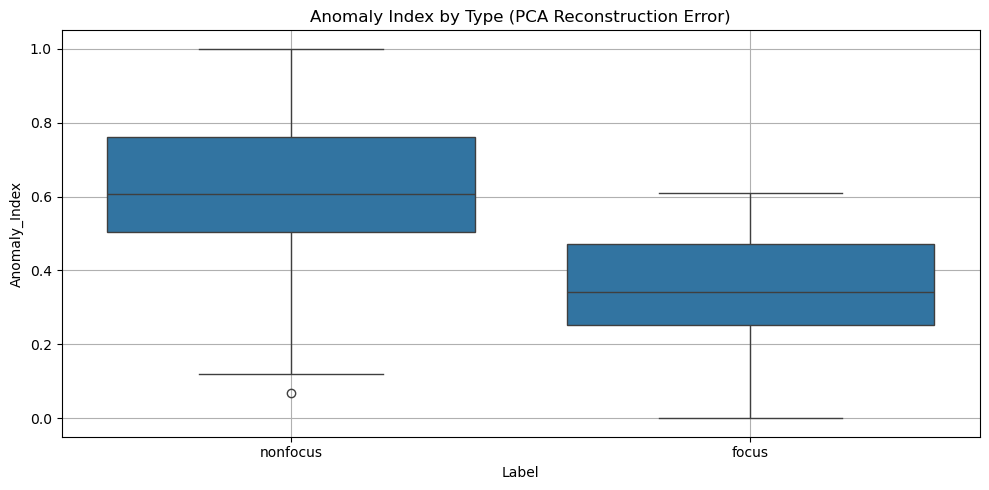

,WAFER_ID,Anomaly_Index,Label
0,wafer1,0.750980,nonfocus
1,wafer10,0.699955,nonfocus
2,wafer11,0.525078,nonfocus
3,wafer12,0.695207,nonfocus
4,wafer13,0.604970,nonfocus
5,wafer14,0.540835,nonfocus
6,wafer15,0.477590,nonfocus
7,wafer16,1.000000,nonfocus
8,wafer17,0.766374,nonfocus
9,wafer18,0.357360,nonfocus


In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
df = data

# 전처리: 각 wafer를 시계열로 재구성
# WAFER_ID별로 PARAMETER_VALUE 시계열을 추출
wafer_data = {
    wafer_id: group["PARAMETER_VALUE"].to_numpy()
    for wafer_id, group in df.groupby("WAFER_ID")
}

# 같은 길이를 가지도록 잘라내거나 보간하지 않고, 일단 길이 기준으로 정렬해 가장 짧은 길이에 맞춰 자름
min_length = min(len(v) for v in wafer_data.values())
wafer_data_trimmed = {
    k: v[:min_length] for k, v in wafer_data.items()
}

# 데이터 행렬로 변환 (wafer x time)
X = np.vstack([v for v in wafer_data_trimmed.values()])
wafer_ids = list(wafer_data_trimmed.keys())

# 정규화 (mean 0, std 1)
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True)
X_norm = (X - X_mean) / X_std

# 주성분 분석 (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)

# 재구성 후 오차 계산 (anomaly index)
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((X_norm - X_reconstructed) ** 2, axis=1)

# 재구성 오차 정규화하여 0~1로 스케일링 (anomaly index)
anomaly_index = (reconstruction_error - reconstruction_error.min()) / (reconstruction_error.max() - reconstruction_error.min())

# 원래 데이터프레임에 anomaly index 붙이기
anomaly_df = pd.DataFrame({
    "WAFER_ID": wafer_ids,
    "Anomaly_Index": anomaly_index
})

# focus 여부 붙이기
label_map = df.drop_duplicates("WAFER_ID").set_index("WAFER_ID")["TYPE"].to_dict()
anomaly_df["Label"] = anomaly_df["WAFER_ID"].map(label_map)

# 시각화: anomaly index 분포
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=anomaly_df, x="Label", y="Anomaly_Index")
plt.title("Anomaly Index by Type (PCA Reconstruction Error)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 반환: anomaly_df 테이블 출력
anomaly_df

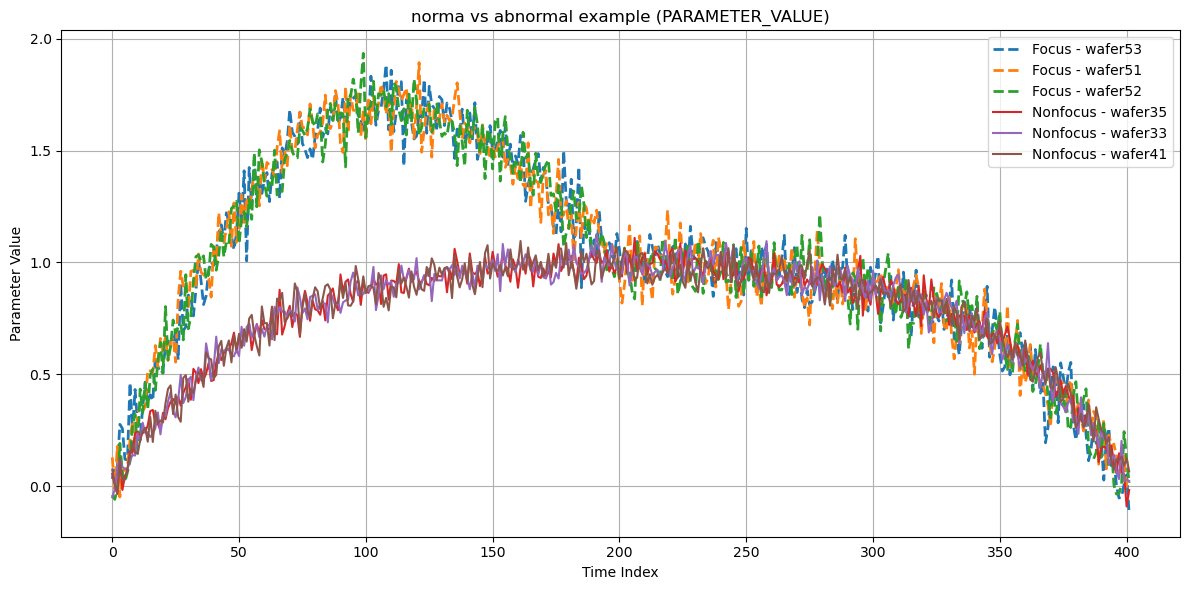

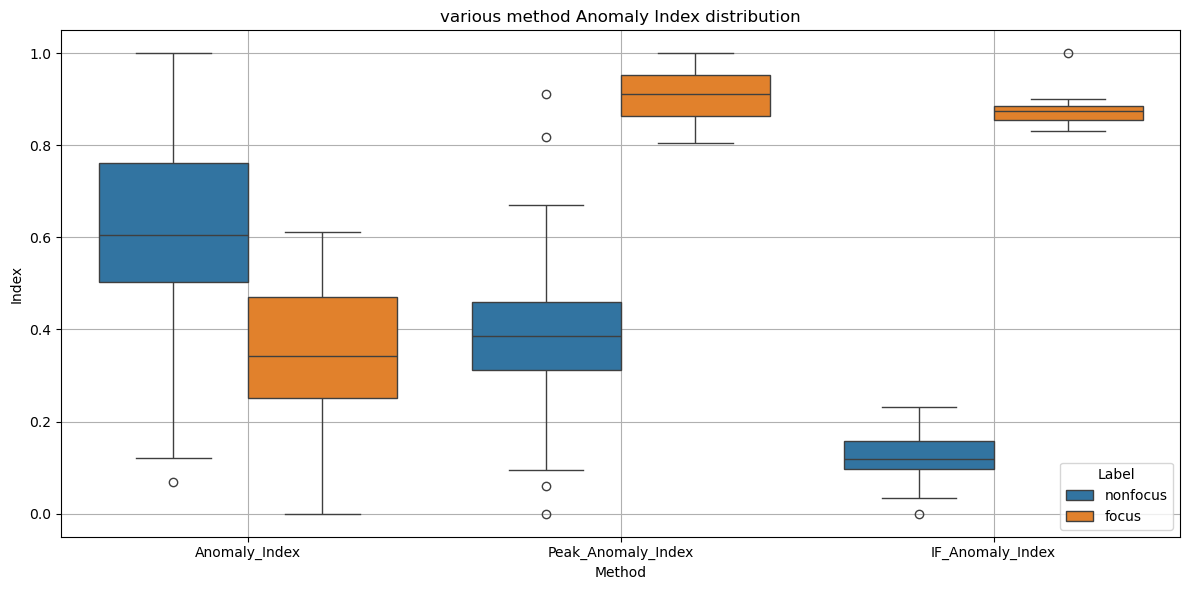

,WAFER_ID,Anomaly_Index,Label,Peak_Anomaly_Index,IF_Anomaly_Index
0,wafer1,0.750980,nonfocus,0.417647,0.119232
1,wafer10,0.699955,nonfocus,0.376471,0.097935
2,wafer11,0.525078,nonfocus,0.911765,0.120042
3,wafer12,0.695207,nonfocus,0.341176,0.108808
4,wafer13,0.604970,nonfocus,0.441176,0.099399
5,wafer14,0.540835,nonfocus,0.564706,0.150083
6,wafer15,0.477590,nonfocus,0.200000,0.165977
7,wafer16,1.000000,nonfocus,0.394118,0.181919
8,wafer17,0.766374,nonfocus,0.588235,0.116007
9,wafer18,0.357360,nonfocus,0.435294,0.139104


In [210]:
# 정상(focus 아님)과 이상(focus) 각각 3개씩 예시를 뽑아서 시계열 곡선 시각화

# focus와 nonfocus로 나눔
focus_ids = anomaly_df[anomaly_df["Label"] == "focus"].sort_values("Anomaly_Index", ascending=False)["WAFER_ID"].head(3).tolist()
nonfocus_ids = anomaly_df[anomaly_df["Label"] == "nonfocus"].sort_values("Anomaly_Index")["WAFER_ID"].head(3).tolist()

# 시계열 시각화
plt.figure(figsize=(12, 6))

# 비정상 곡선
for i, wid in enumerate(focus_ids):
    plt.plot(wafer_data_trimmed[wid], label=f"Focus - {wid}", linestyle="--", linewidth=2)

# 정상 곡선
for i, wid in enumerate(nonfocus_ids):
    plt.plot(wafer_data_trimmed[wid], label=f"Nonfocus - {wid}", linewidth=1.5)

plt.title("norma vs abnormal example (PARAMETER_VALUE)")
plt.xlabel("Time Index")
plt.ylabel("Parameter Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 다른 방법: 피크 인덱스를 기반으로 anomaly index 계산
peak_indices = np.array([
    np.argmax(wafer_data_trimmed[wid])
    for wid in wafer_ids
])

# 피크 인덱스를 정규화 (작을수록 이상)
peak_anomaly_index = (peak_indices.max() - peak_indices) / (peak_indices.max() - peak_indices.min())

# 결과 테이블에 추가
anomaly_df["Peak_Anomaly_Index"] = peak_anomaly_index

# Isolation Forest 기반 anomaly score
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.14, random_state=0)
iso_labels = iso.fit_predict(X_norm)
iso_scores = -iso.decision_function(X_norm)  # 클수록 이상

# 정규화
iso_index = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
anomaly_df["IF_Anomaly_Index"] = iso_index

# 다시 시각화: 3가지 방법 비교 boxplot
melted = anomaly_df.melt(id_vars=["WAFER_ID", "Label"], 
                         value_vars=["Anomaly_Index", "Peak_Anomaly_Index", "IF_Anomaly_Index"],
                         var_name="Method", value_name="Index")

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="Method", y="Index", hue="Label")
plt.title("various method Anomaly Index distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# 갱신된 anomaly_df 테이블 표시
anomaly_df

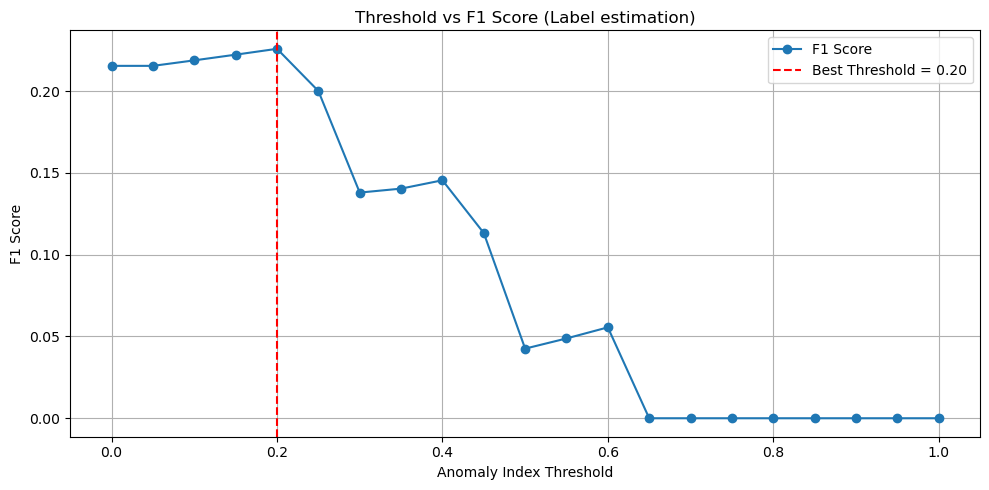

,WAFER_ID,Anomaly_Index,Label,Peak_Anomaly_Index,IF_Anomaly_Index
7,wafer16,1.000000,nonfocus,0.394118,0.181919
32,wafer39,0.938292,nonfocus,0.094118,0.048703
20,wafer28,0.927424,nonfocus,0.382353,0.164183
29,wafer36,0.908712,nonfocus,0.505882,0.168827
57,wafer9,0.905546,nonfocus,0.535294,0.097313
19,wafer27,0.886582,nonfocus,0.535294,0.145055
12,wafer20,0.863464,nonfocus,0.000000,0.230804
56,wafer8,0.831570,nonfocus,0.529412,0.127524
15,wafer23,0.793936,nonfocus,0.058824,0.190873
11,wafer2,0.790793,nonfocus,0.435294,0.146667


In [211]:

thresholds = np.linspace(0, 1, 21)  # 0.0 ~ 1.0 까지 21개 구간
results = []

for th in thresholds:
    pred = anomaly_df["Anomaly_Index"] > th
    tp = np.sum((pred == True) & (anomaly_df["Label"] == "focus"))
    fp = np.sum((pred == True) & (anomaly_df["Label"] == "nonfocus"))
    fn = np.sum((pred == False) & (anomaly_df["Label"] == "focus"))
    tn = np.sum((pred == False) & (anomaly_df["Label"] == "nonfocus"))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    results.append((th, precision, recall, f1))

threshold_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])

# Best F1 기준 threshold 선택
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]

# 이상 웨이퍼 Top-N 정렬
top_n = 10
top_anomalies = anomaly_df.sort_values("Anomaly_Index", ascending=False).head(top_n)

# 시각화: threshold 별 F1 score
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker='o', label="F1 Score")
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Anomaly Index Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score (Label estimation)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 결과 리포트 출력
top_anomalies

In [17]:
test_fd = skfda.FDataGrid(
    data_matrix=test_matrix,
    grid_points=grid_points)

In [19]:
test_set_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(test_fd)
)

In [22]:
test_set = test_set_hat.data_matrix

In [23]:
fd_data = fd.data_matrix.reshape(fd.data_matrix.shape[:-1])
n_samples, n_points_discretization = fd_data.shape # 10, 100

In [25]:
fd_data = fd_data - fd_data.mean() # centering

In [39]:
identity = np.eye(len(fd.grid_points[0]))
weights = scipy.integrate.simpson(identity, x=fd.grid_points[0]) # 적분
weights_matrix = np.diag(weights)